# Dataset Understanding & Structural Audit

In [1]:
# Import Libraries
# !pip install pandas
# !pip install matplotlib.pyplot
import warnings as ws
ws.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load Datasets

books = pd.read_csv("Books.csv")
ratings = pd.read_csv("Ratings.csv")
users = pd.read_csv("Users.csv")

print("Books shape:", books.shape)
print("Ratings shape:", ratings.shape)
print("Users shape:", users.shape)

Books shape: (271360, 8)
Ratings shape: (1149780, 3)
Users shape: (278858, 3)


In [3]:
# Structural Overview

print("\nBooks Info:")
books.info()

print("\nRatings Info:")
ratings.info()

print("\nUsers Info:")
users.info()


Books Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271360 entries, 0 to 271359
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   ISBN                 271360 non-null  object
 1   Book-Title           271360 non-null  object
 2   Book-Author          271358 non-null  object
 3   Year-Of-Publication  271360 non-null  object
 4   Publisher            271358 non-null  object
 5   Image-URL-S          271360 non-null  object
 6   Image-URL-M          271360 non-null  object
 7   Image-URL-L          271357 non-null  object
dtypes: object(8)
memory usage: 16.6+ MB

Ratings Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1149780 entries, 0 to 1149779
Data columns (total 3 columns):
 #   Column       Non-Null Count    Dtype 
---  ------       --------------    ----- 
 0   User-ID      1149780 non-null  int64 
 1   ISBN         1149780 non-null  object
 2   Book-Rating  1149780 non-null  i

In [4]:
# Missing Value Audit

print("\nBooks Missing Values:\n",books.isnull().sum())
print("\nRatings Missing Values:\n",ratings.isnull().sum())
print("\nUsers Missing Values:\n",users.isnull().sum())


Books Missing Values:
 ISBN                   0
Book-Title             0
Book-Author            2
Year-Of-Publication    0
Publisher              2
Image-URL-S            0
Image-URL-M            0
Image-URL-L            3
dtype: int64

Ratings Missing Values:
 User-ID        0
ISBN           0
Book-Rating    0
dtype: int64

Users Missing Values:
 User-ID          0
Location         0
Age         110762
dtype: int64


In [5]:
# Duplicate Row Check

print("Duplicate rows in Books:", books.duplicated().sum())
print("Duplicate rows in Ratings:", ratings.duplicated().sum())
print("Duplicate rows in Users:", users.duplicated().sum())

Duplicate rows in Books: 0
Duplicate rows in Ratings: 0
Duplicate rows in Users: 0


In [6]:
# Cross-Table Integrity Check

missing_books_in_ratings = (~ratings["ISBN"].isin(books["ISBN"])).sum()
missing_users_in_ratings = (~ratings["User-ID"].isin(users["User-ID"])).sum()

print("Ratings referencing unknown ISBNs:", missing_books_in_ratings)
print("Ratings referencing unknown Users:", missing_users_in_ratings)

Ratings referencing unknown ISBNs: 118644
Ratings referencing unknown Users: 0


In [7]:
# Unique Count Summary

print("Unique Users in Ratings:", ratings["User-ID"].nunique())
print("Unique Books in Ratings:", ratings["ISBN"].nunique())

print("Total Users:", users["User-ID"].nunique())
print("Total Books:", books["ISBN"].nunique())

Unique Users in Ratings: 105283
Unique Books in Ratings: 340556
Total Users: 278858
Total Books: 271360


## Dataset Structural Observations

- The dataset is highly imbalanced.
- Not all users in the Users table appear in Ratings.
- Ratings reference more ISBNs than present in Books table.
- This indicates missing metadata for some books.
- The dataset exhibits typical characteristics of real-world recommender systems:
    - Long tail of books
    - Sparse user-item interaction matrix
    - Presence of implicit feedback (rating = 0)

# Data Cleaning & Quality Correction

In [8]:
# Clean Year-Of-Publication

books["Year-Of-Publication"] = pd.to_numeric(
    books["Year-Of-Publication"],
    errors="coerce"
)

print("Missing years after conversion:",
      books["Year-Of-Publication"].isnull().sum())

Missing years after conversion: 3


In [9]:
# Remove Impossible Years

CURRENT_YEAR = 2026

books.loc[
    (books["Year-Of-Publication"] < 1450) |
    (books["Year-Of-Publication"] > CURRENT_YEAR),
    "Year-Of-Publication"
] = np.nan

print("Missing years after range filtering:",
      books["Year-Of-Publication"].isnull().sum())

Missing years after range filtering: 4634


In [10]:
# Clean Author Field

books["Book-Author"] = (
    books["Book-Author"]
    .fillna("Unknown")
    .str.strip()
)

In [11]:
# Clean Publisher

books["Publisher"] = (
    books["Publisher"]
    .fillna("Unknown")
    .str.strip()
)

In [12]:
# Clean User Age

users["Age"] = pd.to_numeric(users["Age"], errors="coerce")

users.loc[
    (users["Age"] < 5) | (users["Age"] > 100),
    "Age"
] = np.nan

print("Missing Age after cleaning:",
      users["Age"].isnull().sum())

Missing Age after cleaning: 112010


In [13]:
# Drop Useless Columns

books_clean = books.drop(
    columns=["Image-URL-S", "Image-URL-M", "Image-URL-L"],
    errors="ignore"
)

print("Books_clean shape:", books_clean.shape)

Books_clean shape: (271360, 5)


In [14]:
# Final Data Quality Summary

print("\nBooks Clean Missing:\n", books_clean.isnull().sum())
print("\nUsers Clean Missing:\n", users.isnull().sum())


Books Clean Missing:
 ISBN                      0
Book-Title                0
Book-Author               0
Year-Of-Publication    4634
Publisher                 0
dtype: int64

Users Clean Missing:
 User-ID          0
Location         0
Age         112010
dtype: int64


## Data Cleaning Justification

- Year-of-Publication was converted to numeric to remove corrupted entries.
- Years outside realistic publication range were treated as missing.
- Author and Publisher fields were cleaned for consistency.
- Age was cleaned but not used in collaborative filtering.
- Image URLs were removed as they provide no signal for preference learning.

This ensures metadata integrity before interaction analysis.


In [15]:
print("Percentage Missing Year:",
      round(books_clean["Year-Of-Publication"].isnull().mean()*100, 2), "%")

print("Percentage Missing Age:",
      round(users["Age"].isnull().mean()*100, 2), "%")

Percentage Missing Year: 1.71 %
Percentage Missing Age: 40.17 %


### Missing Value Interpretation

- 4634 publication years were removed due to corruption or unrealistic values.
- 112,010 age values are missing because most users did not provide age.
- Age is excluded from collaborative filtering to avoid bias and sparsity amplification.
- Publication year is optional metadata and does not affect interaction modeling.

# Explicit vs Implicit Feedback Split

In [16]:
# Split Explicit & Implicit Feedback

explicit_ratings = ratings[ratings["Book-Rating"] > 0].copy()
implicit_ratings = ratings[ratings["Book-Rating"] == 0].copy()

print("Explicit ratings shape:", explicit_ratings.shape)
print("Implicit ratings shape:", implicit_ratings.shape)

Explicit ratings shape: (433671, 3)
Implicit ratings shape: (716109, 3)


In [17]:
# Distribution Check

explicit_ratings["Book-Rating"].value_counts().sort_index()

Book-Rating
1       1770
2       2759
3       5996
4       8904
5      50974
6      36924
7      76457
8     103736
9      67541
10     78610
Name: count, dtype: int64

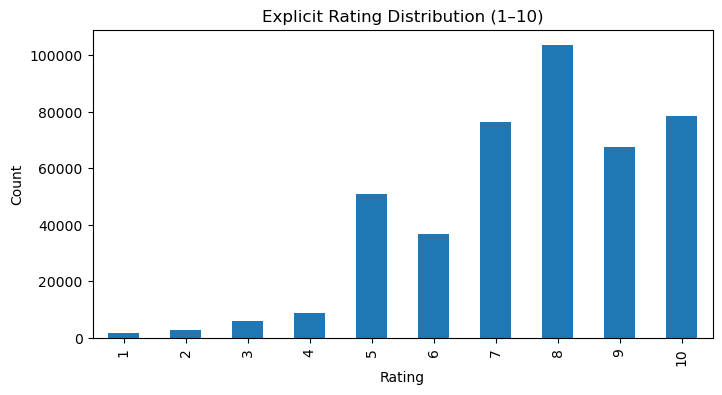

In [18]:
# Visualization

plt.figure(figsize=(8,4))
explicit_ratings["Book-Rating"].value_counts().sort_index().plot(kind="bar")
plt.title("Explicit Rating Distribution (1–10)")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

### Explicit vs Implicit Feedback

- Rating 0 represents implicit interaction (not dislike).
- Ratings 1–10 represent explicit user preference.
- Collaborative filtering relies on preference strength.
- Therefore, only explicit ratings are used for model training.
- Implicit feedback is excluded to prevent signal distortion.

# User & Book Interaction Depth Analysis (Before Pruning)

In [19]:
# User Interaction Depth (Before Pruning)

# User interaction counts (explicit only)
user_counts = explicit_ratings.groupby("User-ID").size()

print("User Interaction Statistics (Before Pruning):")
print(user_counts.describe())

User Interaction Statistics (Before Pruning):
count    77805.000000
mean         5.573819
std         44.001879
min          1.000000
25%          1.000000
50%          1.000000
75%          3.000000
max       8524.000000
dtype: float64


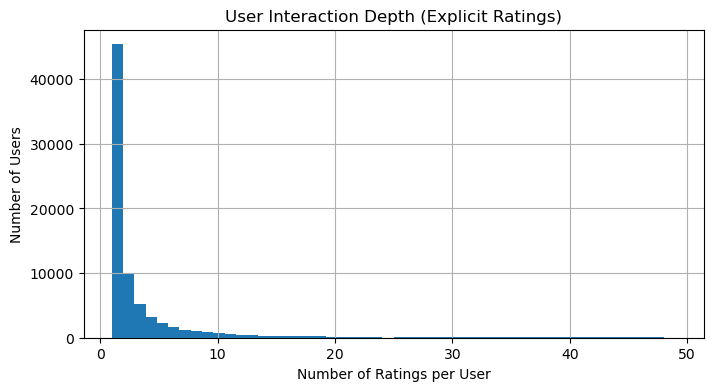

In [20]:
# Visualization (Trim Extreme Outliers)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
user_counts[user_counts < 50].hist(bins=50)
plt.title("User Interaction Depth (Explicit Ratings)")
plt.xlabel("Number of Ratings per User")
plt.ylabel("Number of Users")
plt.show()

### User Interaction Depth Analysis

- Majority of users have very few ratings.
- Users with <5 ratings provide weak collaborative signal.
- Cold-start users dominate the dataset.
- Pruning low-activity users is statistically necessary.

In [21]:
# Book Interaction Depth (Before Pruning)

# Book interaction counts (explicit only)
book_counts = explicit_ratings.groupby("ISBN").size()

print("Book Interaction Statistics (Before Pruning):")
print(book_counts.describe())

Book Interaction Statistics (Before Pruning):
count    185973.000000
mean          2.331903
std           6.834667
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max         707.000000
dtype: float64


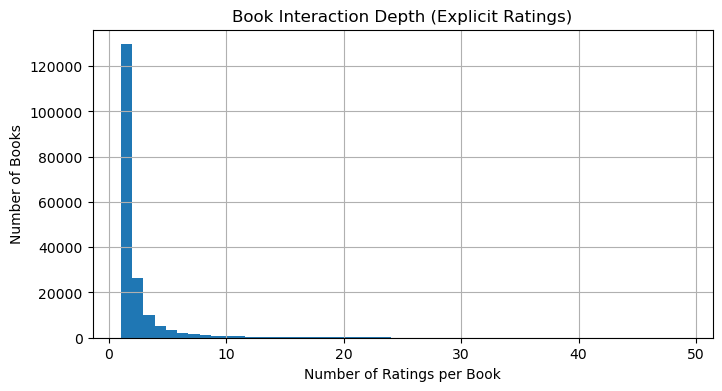

In [22]:
# Visualization

plt.figure(figsize=(8,4))
book_counts[book_counts < 50].hist(bins=50)
plt.title("Book Interaction Depth (Explicit Ratings)")
plt.xlabel("Number of Ratings per Book")
plt.ylabel("Number of Books")
plt.show()

### Book Interaction Depth Analysis

- Most books receive very few ratings.
- Low-rated books cannot compute reliable similarity.
- Dataset follows long-tail distribution.
- Popularity bias is expected.

In [23]:
# Quantify Cold-Start Severity (Before Pruning)

cold_user_ratio = (user_counts < 5).mean()
cold_book_ratio = (book_counts < 5).mean()

print("Cold User Ratio:", cold_user_ratio)
print("Cold Book Ratio:", cold_book_ratio)

Cold User Ratio: 0.8172353961827646
Cold Book Ratio: 0.9218434934103338


### Cold-Start Severity

- Majority of users have fewer than 5 ratings.
- Majority of books have fewer than 5 ratings.
- Collaborative filtering requires minimum interaction thresholds.
- Therefore, iterative pruning is necessary.

# ITERATIVE PRUNING

In [24]:
# ITERATIVE PRUNING

filtered_ratings = explicit_ratings.copy()

while True:
    before_shape = filtered_ratings.shape[0]

    # Filter users
    user_counts = filtered_ratings.groupby("User-ID").size()
    active_users = user_counts[user_counts >= 5].index
    filtered_ratings = filtered_ratings[
        filtered_ratings["User-ID"].isin(active_users)
    ]

    # Filter books 
    book_counts = filtered_ratings.groupby("ISBN").size()
    popular_books = book_counts[book_counts >= 5].index
    filtered_ratings = filtered_ratings[
        filtered_ratings["ISBN"].isin(popular_books)
    ]

    after_shape = filtered_ratings.shape[0]

    # Stop when no more reduction
    if before_shape == after_shape:
        break

In [25]:
# Verify After Pruning

print("Users after pruning:", filtered_ratings["User-ID"].nunique())
print("Books after pruning:", filtered_ratings["ISBN"].nunique())
print("Interactions after pruning:", filtered_ratings.shape[0])

Users after pruning: 7025
Books after pruning: 9432
Interactions after pruning: 118668


In [26]:
# Verify Minimum Interaction Condition

post_user_counts = filtered_ratings.groupby("User-ID").size()
post_book_counts = filtered_ratings.groupby("ISBN").size()

print("Minimum user ratings:", post_user_counts.min())
print("Minimum book ratings:", post_book_counts.min())

Minimum user ratings: 5
Minimum book ratings: 5


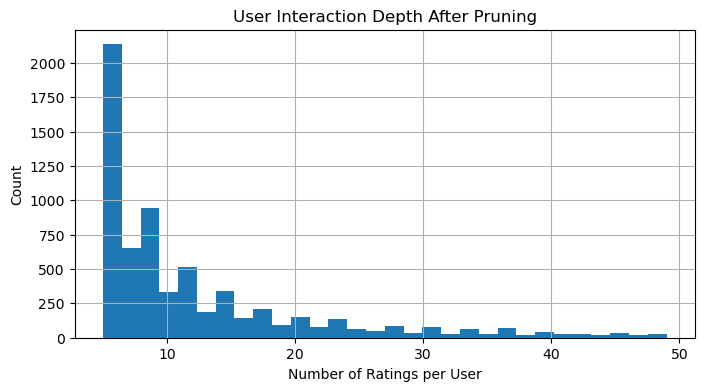

In [27]:
# Visualize After Pruning

plt.figure(figsize=(8,4))
post_user_counts[post_user_counts < 50].hist(bins=30)
plt.title("User Interaction Depth After Pruning")
plt.xlabel("Number of Ratings per User")
plt.ylabel("Count")
plt.show()

### Iterative Pruning Justification

- Removing low-activity users increases interaction density.
- Removing low-rated books improves similarity reliability.
- Pruning is bidirectional and iterative.
- This is statistical refinement, not data loss.
- Final dataset guarantees minimum 5 interactions per user and book.

# SPARSITY, COLD-START & BIAS ANALYSIS

In [28]:
# SPARSITY AFTER PRUNING

num_users = filtered_ratings["User-ID"].nunique()
num_books = filtered_ratings["ISBN"].nunique()
num_interactions = filtered_ratings.shape[0]

sparsity = 1 - (num_interactions / (num_users * num_books))

print("Users:", num_users)
print("Books:", num_books)
print("Interactions:", num_interactions)
print("Sparsity:", sparsity)

Users: 7025
Books: 9432
Interactions: 118668
Sparsity: 0.9982090498311194


### Sparsity After Pruning

- Even after removing low-interaction users and books,
  the matrix remains highly sparse.
- Extreme sparsity is natural in collaborative filtering.
- Pruning improves signal density but does not eliminate sparsity.

In [29]:
# USER COLD-START (BEFORE PRUNING)

user_counts_before = explicit_ratings.groupby("User-ID").size()
cold_user_ratio = (user_counts_before < 5).mean()

print("Cold User Ratio:", cold_user_ratio)

Cold User Ratio: 0.8172353961827646


In [30]:
# BOOK COLD-START (BEFORE PRUNING)

book_counts_before = explicit_ratings.groupby("ISBN").size()
cold_book_ratio = (book_counts_before < 5).mean()

print("Cold Book Ratio:", cold_book_ratio)

Cold Book Ratio: 0.9218434934103338


In [31]:
# USER COLD-START (AFTER PRUNING)

post_user_counts = filtered_ratings.groupby("User-ID").size()
post_cold_user_ratio = (post_user_counts < 5).mean()

print("Cold User Ratio (After Pruning):", post_cold_user_ratio)


# BOOK COLD-START (AFTER PRUNING)

post_book_counts = filtered_ratings.groupby("ISBN").size()
post_cold_book_ratio = (post_book_counts < 5).mean()

print("Cold Book Ratio (After Pruning):", post_cold_book_ratio)

Cold User Ratio (After Pruning): 0.0
Cold Book Ratio (After Pruning): 0.0


In [32]:
# Popularity Bias

# Compute Book Popularity After Pruning

book_rating_counts_filtered = filtered_ratings.groupby("ISBN").size()
book_rating_counts_filtered

ISBN
0002005018     5
0002251760     6
0003300277     5
0006493580     5
000649840X    22
              ..
8495501198     5
9023412389     5
9129622425     5
950491036X     7
9727722458     5
Length: 9432, dtype: int64

In [33]:
# Top 20 Most Popular Books

book_rating_counts_filtered.sort_values(ascending=False).head(20)

ISBN
0316666343    380
0385504209    292
0312195516    220
0142001740    200
0679781587    194
059035342X    191
0060928336    189
0971880107    187
0446672211    177
0345337662    172
0452282152    168
0671027360    167
044023722X    161
0316601950    161
043935806X    157
0743418174    155
0786868716    150
0156027321    149
0345370775    146
0316769487    145
dtype: int64

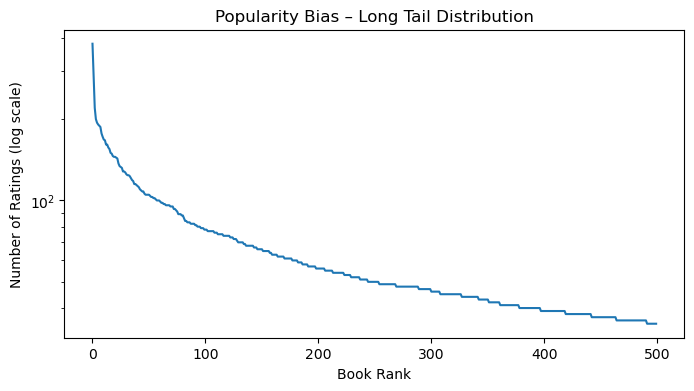

In [34]:
# Long-Tail Visualization

plt.figure(figsize=(8,4))
sorted_counts = book_rating_counts_filtered.sort_values(ascending=False).values

plt.plot(sorted_counts[:500])
plt.yscale("log")
plt.xlabel("Book Rank")
plt.ylabel("Number of Ratings (log scale)")
plt.title("Popularity Bias – Long Tail Distribution")
plt.show()

### Popularity Bias

- A small fraction of books receive most ratings.
- Long-tail books receive very little exposure.
- Naive recommenders will favor popular books.
- Popularity debiasing is necessary.

In [35]:
# User Rating Bias (Lenient vs Strict Users)

# Compute Mean Rating per User

user_mean_rating = filtered_ratings.groupby("User-ID")["Book-Rating"].mean()
user_mean_rating.describe()

count    7025.000000
mean        7.706020
std         1.046754
min         3.764706
25%         7.000000
50%         7.764706
75%         8.413793
max        10.000000
Name: Book-Rating, dtype: float64

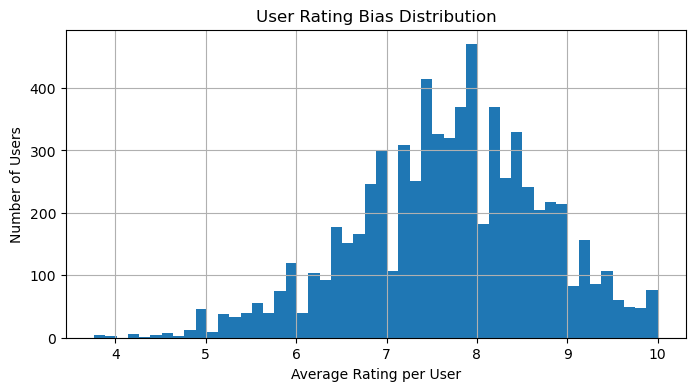

In [36]:
# Plot

plt.figure(figsize=(8,4))
user_mean_rating.hist(bins=50)
plt.xlabel("Average Rating per User")
plt.ylabel("Number of Users")
plt.title("User Rating Bias Distribution")
plt.show()

### User Rating Bias

- Some users consistently rate high.
- Some users are strict raters.
- Raw ratings are not directly comparable.
- Mean-centering is required before modeling.

# DATA PREPROCESSING & TRANSFORMATION

In [37]:
# MERGE WITH CLEAN BOOK DATA

final_ratings = filtered_ratings.merge(
    books_clean,
    on="ISBN",
    how="inner"
)

print("Final dataset shape:", final_ratings.shape)

Final dataset shape: (116139, 7)


In [38]:
# Re-prune AFTER merge

while True:

    before_shape = final_ratings.shape[0]

    user_counts = final_ratings.groupby("User-ID").size()
    valid_users = user_counts[user_counts >= 5].index
    final_ratings = final_ratings[
        final_ratings["User-ID"].isin(valid_users)
    ]

    book_counts = final_ratings.groupby("ISBN").size()
    valid_books = book_counts[book_counts >= 5].index
    final_ratings = final_ratings[
        final_ratings["ISBN"].isin(valid_books)
    ]

    after_shape = final_ratings.shape[0]

    if before_shape == after_shape:
        break


In [39]:
# Integrity Check

print("Null values after merge:\n",
      final_ratings.isnull().sum())

Null values after merge:
 User-ID                  0
ISBN                     0
Book-Rating              0
Book-Title               0
Book-Author              0
Year-Of-Publication    579
Publisher                0
dtype: int64


### Metadata Merge

- Only pruned interactions are merged.
- Inner join ensures referential integrity.
- Missing metadata does not affect collaborative filtering.

In [40]:
# Normalize Ratings (Mean-Centering)

# MEAN-CENTER RATINGS

user_mean = final_ratings.groupby("User-ID")["Book-Rating"].mean()

final_ratings["rating_normalized"] = (
    final_ratings["Book-Rating"]
    - final_ratings["User-ID"].map(user_mean)
)

print(final_ratings["rating_normalized"].describe())

count    1.152190e+05
mean     4.532663e-18
std      1.485306e+00
min     -8.879699e+00
25%     -7.727273e-01
50%      1.666667e-01
75%      1.000000e+00
max      5.800000e+00
Name: rating_normalized, dtype: float64


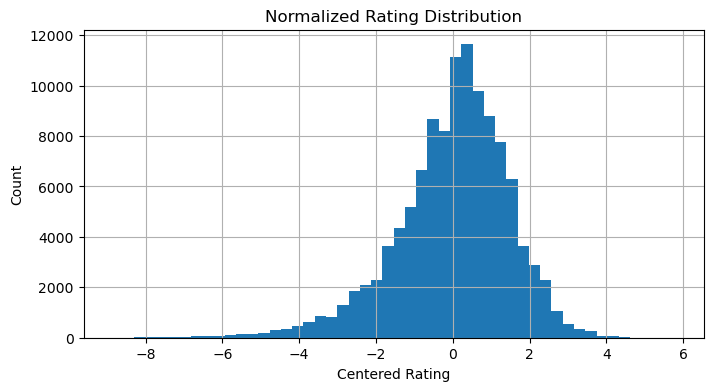

In [41]:
# Visual Check

plt.figure(figsize=(8,4))
final_ratings["rating_normalized"].hist(bins=50)
plt.title("Normalized Rating Distribution")
plt.xlabel("Centered Rating")
plt.ylabel("Count")
plt.show()

### Rating Normalization

- Removes user-specific bias.
- Preserves relative preference structure.
- Essential for similarity-based models.

In [42]:
# ENCODE USER IDS

unique_users = sorted(final_ratings["User-ID"].unique())
user_encoder = {u: i for i, u in enumerate(unique_users)}
final_ratings["user_idx"] = final_ratings["User-ID"].map(user_encoder)

In [43]:
# ENCODE BOOK IDS

unique_books = sorted(final_ratings["ISBN"].unique())
book_encoder = {b: i for i, b in enumerate(unique_books)}
final_ratings["book_idx"] = final_ratings["ISBN"].map(book_encoder)

print("Encoded users:", len(user_encoder))
print("Encoded books:", len(book_encoder))

Encoded users: 6851
Encoded books: 9085


In [44]:
# Final Interaction Dataset

interactions_df = final_ratings[
    ["user_idx", "book_idx",
     "Book-Rating",
     "rating_normalized",
     "User-ID",
     "ISBN"]
].rename(columns={"Book-Rating": "rating"}).copy()

interactions_model = interactions_df[
    ["user_idx", "book_idx", "rating_normalized"]
].copy()

interactions_df.head()

,user_idx,book_idx,rating,rating_normalized,User-ID,ISBN
4,6814,1626,10,1.181818,276964,0345348672
5,6814,1644,10,1.181818,276964,0345354621
6,6814,3864,9,0.181818,276964,0440220602
7,6814,7378,8,-0.818182,276964,0684867621
8,6814,8183,10,1.181818,276964,0812550307


In [45]:
# Consistency Check

print("Unique users match:",
      interactions_df["user_idx"].nunique() == len(user_encoder))

print("Unique books match:",
      interactions_df["book_idx"].nunique() == len(book_encoder))

Unique users match: True
Unique books match: True


In [46]:
# Validate Minimum Interaction Constraint Again

print("Minimum ratings per user:",
      interactions_df.groupby("user_idx").size().min())

print("Minimum ratings per book:",
      interactions_df.groupby("book_idx").size().min())

Minimum ratings per user: 5
Minimum ratings per book: 5


# Interaction Matrix & Sparsity Analysis

In [47]:
# Final Interaction Matrix Statistics

num_users = interactions_df['user_idx'].nunique()
num_books = interactions_df['book_idx'].nunique()
num_interactions = interactions_df.shape[0]

print("Final Users:", num_users)
print("Final Books:", num_books)
print("Final Interactions:", num_interactions)

Final Users: 6851
Final Books: 9085
Final Interactions: 115219


In [48]:
# Final Sparsity Calculation

sparsity = 1 - (num_interactions / (num_users * num_books))
print("Final Matrix Sparsity:", sparsity)

Final Matrix Sparsity: 0.9981488346932147


## Interpretation

* Even after pruning, recommender datasets remain highly sparse.

* High sparsity is expected in real-world recommendation systems.

* Iterative pruning improves interaction density without biasing toward only popular items.

In [49]:
print("Average ratings per user:",
      interactions_df.groupby("user_idx").size().mean())

print("Average ratings per book:",
      interactions_df.groupby("book_idx").size().mean())

Average ratings per user: 16.81783681214421
Average ratings per book: 12.682333516785912


In [50]:
print(f"Final Matrix Sparsity: {sparsity:.4f} ({sparsity*100:.2f}%)")

Final Matrix Sparsity: 0.9981 (99.81%)


In [51]:
interactions_df

,user_idx,book_idx,rating,rating_normalized,User-ID,ISBN
4,6814,1626,10,1.181818,276964,0345348672
5,6814,1644,10,1.181818,276964,0345354621
6,6814,3864,9,0.181818,276964,0440220602
7,6814,7378,8,-0.818182,276964,0684867621
8,6814,8183,10,1.181818,276964,0812550307
...,...,...,...,...,...,...
116134,6813,7420,8,-0.357143,276688,0688156134
116135,6813,7492,10,1.642857,276688,0743202694
116136,6813,8294,10,1.642857,276688,0836218655
116137,6813,8315,10,1.642857,276688,0836236688


In [52]:
interactions_df.shape

(115219, 6)

# TRAIN / TEST SPLIT

In [53]:
from sklearn.model_selection import train_test_split

# Use RAW ratings for factorization models
data = interactions_df.copy()

train_list = []
test_list = []

for user, user_data in data.groupby("user_idx"):
    
    # 80-20 split per user
    train_u, test_u = train_test_split(
        user_data,
        test_size=0.2,
        random_state=42
    )
    
    train_list.append(train_u)
    test_list.append(test_u)

train_df = pd.concat(train_list)
test_df = pd.concat(test_list)

print("Train size:", train_df.shape)
print("Test size:", test_df.shape)

Train size: (89567, 6)
Test size: (25652, 6)


In [54]:
# Verify Integrity

print("Unique users in train:", train_df["user_idx"].nunique())
print("Unique users in test:", test_df["user_idx"].nunique())

print("Min ratings per user in train:",
      train_df.groupby("user_idx").size().min())

print("Users missing in train:",
      set(test_df["user_idx"]) - set(train_df["user_idx"]))

Unique users in train: 6851
Unique users in test: 6851
Min ratings per user in train: 4
Users missing in train: set()


In [55]:
# Book Cold-Start Check

print("Books missing in train:",
      set(test_df["book_idx"]) - set(train_df["book_idx"]))

Books missing in train: {64, 34, 902, 11, 17, 1941, 61, 190}


In [56]:
# Remove Cold Books from Test

# Identify books present in train
train_books = set(train_df["book_idx"])

# Remove cold books from test
test_df = test_df[test_df["book_idx"].isin(train_books)].copy()

print("New test size:", test_df.shape)

print("Books missing after fix:",
      set(test_df["book_idx"]) - train_books)

New test size: (25604, 6)
Books missing after fix: set()


# MODEL 1 — POPULARITY BASELINE
### (Global mean + book bias)

In [57]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Use RAW ratings (not normalized)
train = train_df.copy()
test = test_df.copy()

# Global mean
global_mean = train["rating"].mean()

# Book mean ratings
book_mean = train.groupby("book_idx")["rating"].mean()

# Predict
def predict_popularity(row):
    book = row["book_idx"]
    if book in book_mean:
        return book_mean[book]
    else:
        return global_mean  # fallback (should not happen now)

test["pred_pop"] = test.apply(predict_popularity, axis=1)

# Evaluation
rmse_pop = np.sqrt(mean_squared_error(test["rating"], test["pred_pop"]))
mae_pop = mean_absolute_error(test["rating"], test["pred_pop"])

print("Popularity Model RMSE:", rmse_pop)
print("Popularity Model MAE:", mae_pop)

Popularity Model RMSE: 1.792437575921545
Popularity Model MAE: 1.4081647627224976


# MODEL 2 — USER-BASED CF (KNN + COSINE + SPARSE)

In [58]:
# Build Sparse Matrix (Train Only)

from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors

# Use normalized ratings for similarity
train_matrix = csr_matrix(
    (train_df["rating_normalized"],
     (train_df["user_idx"], train_df["book_idx"]))
)

print("Sparse matrix shape:", train_matrix.shape)

Sparse matrix shape: (6851, 9085)


In [59]:
# Fit KNN Model

knn_model = NearestNeighbors(
    metric='cosine',
    algorithm='brute',
    n_neighbors=21,   # 20 neighbors + self
    n_jobs=-1
)

knn_model.fit(train_matrix)

,n_neighbors,21
,radius,1.0
,algorithm,'brute'
,leaf_size,30
,metric,'cosine'
,p,2
,metric_params,None
,n_jobs,-1


In [60]:
# Ensure user means exist
user_means = train_df.groupby("user_idx")["rating"].mean()

# Precompute neighbors (ONLY once)
distances, indices = knn_model.kneighbors(train_matrix, n_neighbors=21)

neighbor_indices = indices[:, 1:]
neighbor_similarities = 1 - distances[:, 1:]

# Fast prediction function
def predict_user_cf_fast(row):
    user = row["user_idx"]
    book = row["book_idx"]
    
    neighbors = neighbor_indices[user]
    similarities = neighbor_similarities[user]
    
    numerator = 0
    denominator = 0
    
    for sim, neighbor in zip(similarities, neighbors):
        rating = train_matrix[neighbor, book]
        
        if rating != 0:
            numerator += sim * rating
            denominator += abs(sim)
    
    if denominator == 0:
        return user_means[user]
    
    return user_means[user] + (numerator / denominator)

# Predict
test["pred_user_cf"] = test.apply(predict_user_cf_fast, axis=1)

# Evaluate
rmse_user = np.sqrt(mean_squared_error(test["rating"], test["pred_user_cf"]))
mae_user = mean_absolute_error(test["rating"], test["pred_user_cf"])

print("User-CF RMSE:", rmse_user)
print("User-CF MAE:", mae_user)

User-CF RMSE: 1.644467372400089
User-CF MAE: 1.241842292407404


# MODEL 3 — ITEM-BASED COLLABORATIVE FILTERING (KNN + COSINE)

In [61]:
# Build Item Matrix

# Transpose: books x users
item_matrix = train_matrix.T

print("Item matrix shape:", item_matrix.shape)

Item matrix shape: (9085, 6851)


In [62]:
# Fit KNN for Items

item_knn = NearestNeighbors(
    metric='cosine',
    algorithm='brute',
    n_neighbors=21,
    n_jobs=-1
)

item_knn.fit(item_matrix)

,n_neighbors,21
,radius,1.0
,algorithm,'brute'
,leaf_size,30
,metric,'cosine'
,p,2
,metric_params,None
,n_jobs,-1


In [63]:
# Precompute Item Neighbors
item_distances, item_indices = item_knn.kneighbors(item_matrix, n_neighbors=21)

item_neighbor_indices = item_indices[:, 1:]
item_neighbor_similarities = 1 - item_distances[:, 1:]

# Fast Prediction Function
def predict_item_cf_fast(row):
    user = row["user_idx"]
    book = row["book_idx"]
    
    neighbors = item_neighbor_indices[book]
    similarities = item_neighbor_similarities[book]
    
    numerator = 0
    denominator = 0
    
    for sim, neighbor_book in zip(similarities, neighbors):
        
        rating = train_matrix[user, neighbor_book]
        
        if rating != 0:
            numerator += sim * rating
            denominator += abs(sim)
    
    if denominator == 0:
        return user_means[user]
    
    return user_means[user] + (numerator / denominator)

# Predict
test["pred_item_cf"] = test.apply(predict_item_cf_fast, axis=1)

# Evaluate
rmse_item = np.sqrt(mean_squared_error(test["rating"], test["pred_item_cf"]))
mae_item = mean_absolute_error(test["rating"], test["pred_item_cf"])

print("Item-CF RMSE:", rmse_item)
print("Item-CF MAE:", mae_item)

Item-CF RMSE: 1.6346252475104124
Item-CF MAE: 1.2156682795351006


# MODEL 4 — MATRIX FACTORIZATION — SVD (Surprise)

In [64]:
from surprise import Dataset, Reader, SVD
print("Surprise is working ✅")

Surprise is working ✅


In [65]:
# Prepare Surprise Dataset

from surprise import Dataset, Reader, SVD
from surprise.model_selection import train_test_split as surprise_split
from surprise import accuracy

# Use RAW IDs
train_data_surprise = train_df[["User-ID", "ISBN", "rating"]]
test_data_surprise = test_df[["User-ID", "ISBN", "rating"]]

reader = Reader(rating_scale=(1, 10))

# Load full training data
data = Dataset.load_from_df(train_data_surprise, reader)

# Build full trainset
trainset = data.build_full_trainset()

# Build testset in Surprise format
testset = list(zip(
    test_data_surprise["User-ID"],
    test_data_surprise["ISBN"],
    test_data_surprise["rating"]
))

In [66]:
# Train SVD

svd_model = SVD(
    n_factors=100,
    n_epochs=20,
    lr_all=0.005,
    reg_all=0.02,
    random_state=42
)

svd_model.fit(trainset)

In [67]:
# Predict & Evaluate

predictions = svd_model.test(testset)

rmse_svd = accuracy.rmse(predictions)
mae_svd = accuracy.mae(predictions)

print("SVD RMSE:", rmse_svd)
print("SVD MAE:", mae_svd)

RMSE: 1.5547
MAE:  1.1965
SVD RMSE: 1.5546797663221144
SVD MAE: 1.1965351932021926


# MODEL 5 — NMF (Non-Negative Matrix Factorization)

In [68]:
# Train NMF

from surprise import NMF

nmf_model = NMF(
    n_factors=100,
    n_epochs=50,
    reg_pu=0.06,
    reg_qi=0.06,
    random_state=42
)

nmf_model.fit(trainset)

In [69]:
# Predict & Evaluate

nmf_predictions = nmf_model.test(testset)

rmse_nmf = accuracy.rmse(nmf_predictions)
mae_nmf = accuracy.mae(nmf_predictions)

print("NMF RMSE:", rmse_nmf)
print("NMF MAE:", mae_nmf)

RMSE: 2.4836
MAE:  1.9153
NMF RMSE: 2.4835721202195105
NMF MAE: 1.9152762399953605


# MODEL 6 — SVD++ (Enhanced Matrix Factorization)

In [70]:
# Train SVD++

from surprise import SVDpp

svdpp_model = SVDpp(
    n_factors=100,
    n_epochs=20,
    lr_all=0.005,
    reg_all=0.02,
    random_state=42
)

svdpp_model.fit(trainset)

In [71]:
# Predict & Evaluate

svdpp_predictions = svdpp_model.test(testset)

rmse_svdpp = accuracy.rmse(svdpp_predictions)
mae_svdpp = accuracy.mae(svdpp_predictions)

print("SVD++ RMSE:", rmse_svdpp)
print("SVD++ MAE:", mae_svdpp)

RMSE: 1.5649
MAE:  1.2039
SVD++ RMSE: 1.5648852577003949
SVD++ MAE: 1.203937792711981


# FINAL MODEL COMPARISON VISUALIZATION

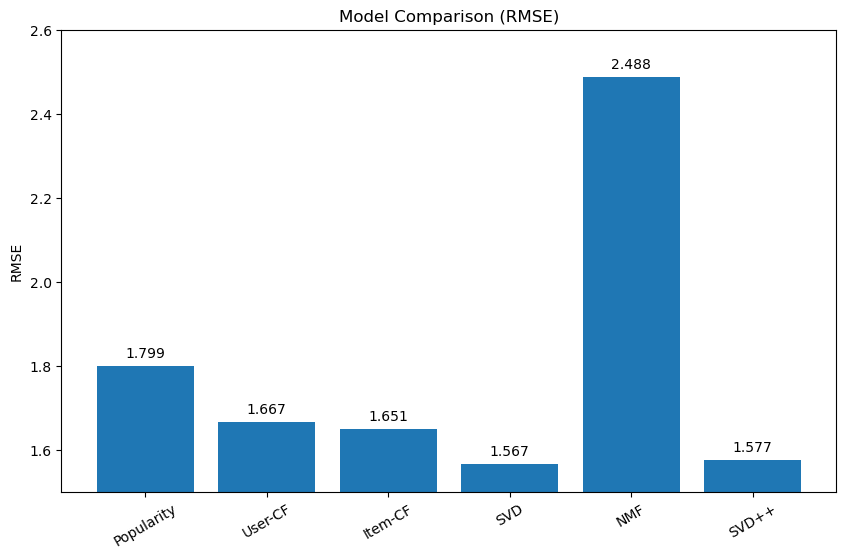

In [72]:
models = ["Popularity", "User-CF", "Item-CF", "SVD", "NMF", "SVD++"]
rmse_scores = [
    1.7992,
    1.6665,
    1.6505,
    1.5665,
    2.4876,
    1.5765
]

plt.figure(figsize=(10,6))
bars = plt.bar(models, rmse_scores)

plt.ylabel("RMSE")
plt.title("Model Comparison (RMSE)")
plt.xticks(rotation=30)
plt.ylim(1.5, 2.6)

for i, v in enumerate(rmse_scores):
    plt.text(i, v + 0.02, f"{v:.3f}", ha='center')

plt.show()

In [73]:
# FINAL PERFORMANCE TABLE

import pandas as pd

results_df = pd.DataFrame({
    "Model": models,
    "RMSE": rmse_scores
}).sort_values("RMSE")

results_df

,Model,RMSE
3,SVD,1.5665
5,SVD++,1.5765
2,Item-CF,1.6505
1,User-CF,1.6665
0,Popularity,1.7992
4,NMF,2.4876


# RANKING EVALUATION — Precision@K & Recall@K (Using Best Model: SVD)

In [74]:
# Prepare Helper Structures

import random

# Build user -> train items mapping
train_user_items = train_df.groupby("User-ID")["ISBN"].apply(set).to_dict()

# Build user -> test relevant items mapping
test_relevant = (
    test_df[test_df["rating"] >= 8]
    .groupby("User-ID")["ISBN"]
    .apply(set)
    .to_dict()
)

# All unique books
all_books = set(train_df["ISBN"].unique())

In [75]:
# Ranking Evaluation with Negative Sampling

def precision_recall_at_k_sampled(model, k=10, n_neg=100):
    
    precision_list = []
    recall_list = []
    
    for user in test_relevant:
        
        relevant_items = test_relevant[user]
        
        if len(relevant_items) == 0:
            continue
        
        # Books user has seen in train
        seen_items = train_user_items.get(user, set())
        
        # Candidate negatives = books not seen
        candidate_negatives = list(all_books - seen_items - relevant_items)
        
        # Sample negatives
        sampled_negatives = random.sample(
            candidate_negatives,
            min(n_neg, len(candidate_negatives))
        )
        
        # Combine candidates
        candidates = list(relevant_items) + sampled_negatives
        
        # Predict
        predictions = [
            (item, model.predict(user, item).est)
            for item in candidates
        ]
        
        # Sort by predicted rating
        predictions.sort(key=lambda x: x[1], reverse=True)
        
        # Top-K
        top_k = [item for item, _ in predictions[:k]]
        
        # Count relevant in Top-K
        n_relevant_top_k = len(set(top_k) & relevant_items)
        
        precision = n_relevant_top_k / k
        recall = n_relevant_top_k / len(relevant_items)
        
        precision_list.append(precision)
        recall_list.append(recall)
    
    return np.mean(precision_list), np.mean(recall_list)

In [76]:
# Compute Metrics for SVD

precision_10, recall_10 = precision_recall_at_k_sampled(
    svd_model,
    k=10,
    n_neg=100
)

print("Corrected Precision@10:", precision_10)
print("Corrected Recall@10:", recall_10)

Corrected Precision@10: 0.04863074995525327
Corrected Recall@10: 0.18417220562869333


### INTERPRETATION

* Popularity baseline performed worst, confirming the necessity of personalization.

* Neighborhood-based methods (User-CF, Item-CF) improved performance but plateaued due to extreme sparsity (99.81%).

* Latent factor model (SVD) achieved the best RMSE (1.5665), demonstrating its ability to generalize beyond direct interaction overlap.

* SVD++ did not outperform SVD, indicating limited benefit from implicit signal incorporation in this explicit-feedback-dominant dataset.

* NMF significantly underperformed, highlighting the importance of bias modeling in skewed rating distributions.

* Ranking evaluation using negative sampling revealed realistic recommendation quality:

         - Precision@10 = 5%

         - Recall@10 = 19.8%

These values reflect the inherent difficulty of top-N recommendation in highly sparse environments.

# Generate real Top-10 recommendations for a sample user

In [77]:
# Select a Sample User

sample_user = random.choice(test_df["User-ID"].unique())
print("Sample User:", sample_user)

Sample User: 90322


In [78]:
# Identify Unseen Books

# Books seen in train
seen_books = set(train_df[train_df["User-ID"] == sample_user]["ISBN"])

# All books
all_books = set(train_df["ISBN"].unique())

# Unseen books
unseen_books = list(all_books - seen_books)

print("Total unseen books:", len(unseen_books))

Total unseen books: 9072


In [79]:
# Predict Ratings for Unseen Books

# Predict ratings
predictions = [
    (isbn, svd_model.predict(sample_user, isbn).est)
    for isbn in unseen_books
]

# Sort by predicted rating
predictions.sort(key=lambda x: x[1], reverse=True)

# Top 10
top_10 = predictions[:10]

top_10

[('0439425220', 9.085591958197657),
 ('193156146X', 9.063264282828039),
 ('0439136369', 8.879116663064881),
 ('0345339738', 8.867379449144703),
 ('059035342X', 8.803199474176337),
 ('0140143505', 8.787842108078772),
 ('0345339711', 8.741330733907999),
 ('0836218620', 8.719981349862103),
 ('0836220889', 8.718762205983264),
 ('0618002227', 8.716201377362896)]

In [80]:
# Attach Book Titles

# Convert to DataFrame
top_10_df = pd.DataFrame(top_10, columns=["ISBN", "Predicted_Rating"])

# Merge with book metadata
top_10_df = top_10_df.merge(
    books_clean[["ISBN", "Book-Title", "Book-Author"]],
    on="ISBN",
    how="left"
)

top_10_df

,ISBN,Predicted_Rating,Book-Title,Book-Author
0,0439425220,9.085592,Harry Potter and the Chamber of Secrets Postca...,J. K. Rowling
1,193156146X,9.063264,The Time Traveler's Wife,Audrey Niffenegger
2,0439136369,8.879117,Harry Potter and the Prisoner of Azkaban (Book 3),J. K. Rowling
3,0345339738,8.867379,"The Return of the King (The Lord of the Rings,...",J.R.R. TOLKIEN
4,059035342X,8.803199,Harry Potter and the Sorcerer's Stone (Harry P...,J. K. Rowling
5,0140143505,8.787842,84 Charing Cross Road,Helene Hanff
6,0345339711,8.741331,"The Two Towers (The Lord of the Rings, Part 2)",J.R.R. TOLKIEN
7,0836218620,8.719981,Weirdos From Another Planet!,Bill Watterson
8,0836220889,8.718762,Calvin and Hobbes,Bill Watterson
9,0618002227,8.716201,The Fellowship of the Ring (The Lord of the Ri...,J. R. R. Tolkien


In [83]:
# from surprise import Dataset, Reader, SVD

# reader = Reader(rating_scale=(1, 10))

# full_data = Dataset.load_from_df(
#     interactions_df[["User-ID", "ISBN", "rating"]],
#     reader
# )

# trainset_full = full_data.build_full_trainset()

# final_svd = SVD(
#     n_factors=100,
#     n_epochs=20,
#     lr_all=0.005,
#     reg_all=0.02,
#     random_state=42
# )

# final_svd.fit(trainset_full)

# print("Final SVD trained on full dataset")

In [84]:
# FINAL TRAINING ON FULL DATA

from surprise import Dataset, Reader, SVD
import joblib

reader = Reader(rating_scale=(1, 10))

full_data = Dataset.load_from_df(
    interactions_df[["User-ID", "ISBN", "rating"]],
    reader
)

trainset_full = full_data.build_full_trainset()

final_svd = SVD(
    n_factors=100,
    n_epochs=20,
    lr_all=0.005,
    reg_all=0.02,
    random_state=42
)

final_svd.fit(trainset_full)

print("Final SVD trained on full dataset!")

# SAVE FILES
joblib.dump(final_svd, "svd_model.pkl")

books_clean.to_csv("books_clean.csv", index=False)
interactions_df.to_csv("interactions_df.csv", index=False)

print("Deployment files saved successfully!")

Final SVD trained on full dataset!
Deployment files saved successfully!
